# MachineGuard — NASA IMS Data Exploration

## Goal

This notebook explores the structure of the NASA IMS Bearing Dataset before any signal processing or machine learning is performed.

We will begin by:

- loading one vibration snapshot from the first test-to-failure experiment;
- verifying the number of samples and sensor channels;
- assigning meaningful names to the accelerometer channels;
- inspecting the raw vibration measurements.

In [101]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load a vibration snapshot

We begin by loading one measurement file from the first run-to-failure experiment.

The selected file is:

`2003.10.22.12.06.24`

This file represents a vibration snapshot collected on October 22, 2003 at 12:06:24.

According to the IMS dataset documentation, each file contains 20,480 samples from the sensor channels recorded during that snapshot.

In [102]:
file_path = Path("../data/raw/IMS/1st_test/2003.10.22.12.06.24")
file_path

PosixPath('../data/raw/IMS/1st_test/2003.10.22.12.06.24')

In [103]:
file_path.exists()

True

In [104]:
df = pd.read_csv(
    file_path,
    sep="\t",
    header=None
)

## 2. Inspect the loaded data

Before processing the vibration signal, we verify that the file has been loaded correctly and that its structure matches the dataset documentation.

For Set 1, we expect:

- 20,480 samples;
- 8 accelerometer channels;
- no missing header row, since the raw file contains only numerical measurements.

In [105]:
df.head()

,0,1,2,3,4,5,6,7
0,-0.022,-0.039,-0.183,-0.054,-0.105,-0.134,-0.129,-0.142
1,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
2,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
3,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
4,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066


In [106]:
df.shape

(20480, 8)

In [107]:
df.dtypes

0    float64
1    float64
2    float64
3    float64
4    float64
5    float64
6    float64
7    float64
dtype: object

In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20480 entries, 0 to 20479
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       20480 non-null  float64
 1   1       20480 non-null  float64
 2   2       20480 non-null  float64
 3   3       20480 non-null  float64
 4   4       20480 non-null  float64
 5   5       20480 non-null  float64
 6   6       20480 non-null  float64
 7   7       20480 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [109]:
df.isna().sum()

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64

In [110]:
df.describe()

,0,1,2,3,4,5,6,7
count,20480.000000,20480.00000,20480.000000,20480.000000,20480.000000,20480.000000,20480.000000,20480.000000
mean,-0.094593,-0.09388,-0.093817,-0.093752,-0.090812,-0.090881,-0.090969,-0.094235
std,0.081124,0.07065,0.090650,0.077510,0.091463,0.095488,0.060086,0.066382
min,-0.720000,-0.56400,-0.674000,-0.530000,-0.496000,-0.784000,-0.413000,-0.471000
25%,-0.146000,-0.13900,-0.156000,-0.146000,-0.151000,-0.154000,-0.129000,-0.134000
50%,-0.095000,-0.09300,-0.093000,-0.093000,-0.090000,-0.090000,-0.090000,-0.095000
75%,-0.042000,-0.04900,-0.032000,-0.042000,-0.029000,-0.029000,-0.054000,-0.054000
max,0.388000,0.70100,0.359000,0.256000,0.400000,0.415000,0.249000,0.374000


### Initial validation

The vibration file was loaded successfully and matches the documented Set 1 structure:

- 20,480 samples;
- 8 accelerometer channels;
- numerical sensor values;
- no missing measurements in the selected snapshot.

We can now assign meaningful names to the channels before beginning signal visualization and analysis.

## 3. Assign meaningful channel names

Set 1 contains 8 accelerometer channels, with two channels per bearing corresponding to the x- and y-axes.

To make the DataFrame easier to interpret, we replace the default numeric column names with descriptive sensor names.

In [111]:
df.columns = [
    "bearing_1_x",
    "bearing_1_y",
    "bearing_2_x",
    "bearing_2_y",
    "bearing_3_x",
    "bearing_3_y",
    "bearing_4_x",
    "bearing_4_y",
]

df.head()

,bearing_1_x,bearing_1_y,bearing_2_x,bearing_2_y,bearing_3_x,bearing_3_y,bearing_4_x,bearing_4_y
0,-0.022,-0.039,-0.183,-0.054,-0.105,-0.134,-0.129,-0.142
1,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
2,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
3,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
4,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066


## 4. Create the within-snapshot time axis

The vibration measurements are sampled at 20 kHz.

This means that consecutive rows are separated by 1/20,000 seconds, or 50 microseconds.

We create a time axis so that the vibration signal can be plotted against physical time rather than row number.

In [112]:
sampling_rate = 20_000

time = np.arange(len(df)) / sampling_rate
time[:5]

array([0.0e+00, 5.0e-05, 1.0e-04, 1.5e-04, 2.0e-04])

## 5. Visualize one vibration channel

We now plot the x-axis accelerometer signal from Bearing 1.

The x-axis represents time within the vibration snapshot, while the y-axis represents the recorded accelerometer signal.

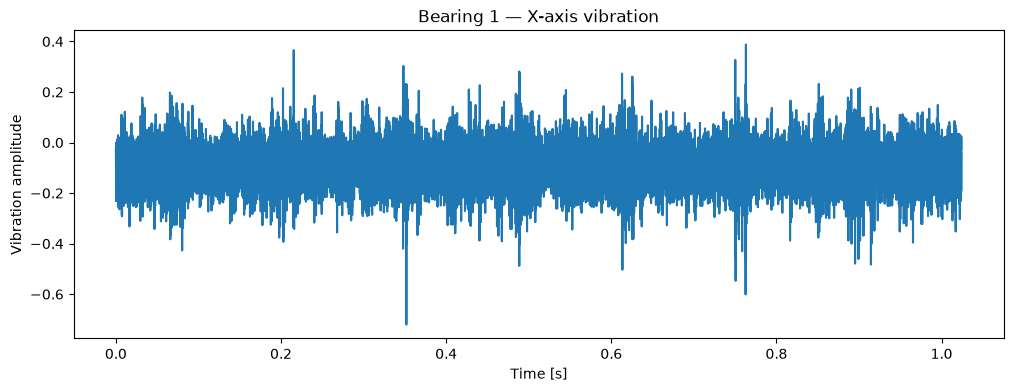

In [113]:
plt.figure(figsize=(12, 4))

plt.plot(time, df["bearing_1_x"])

plt.xlabel("Time [s]")
plt.ylabel("Vibration amplitude")
plt.title("Bearing 1 — X-axis vibration")

plt.show()

### 5.1 Zoom into the vibration waveform

The complete snapshot contains 20,480 samples, making the full signal visually dense.

To inspect the waveform more clearly, we zoom into the first 50 milliseconds of the recording.

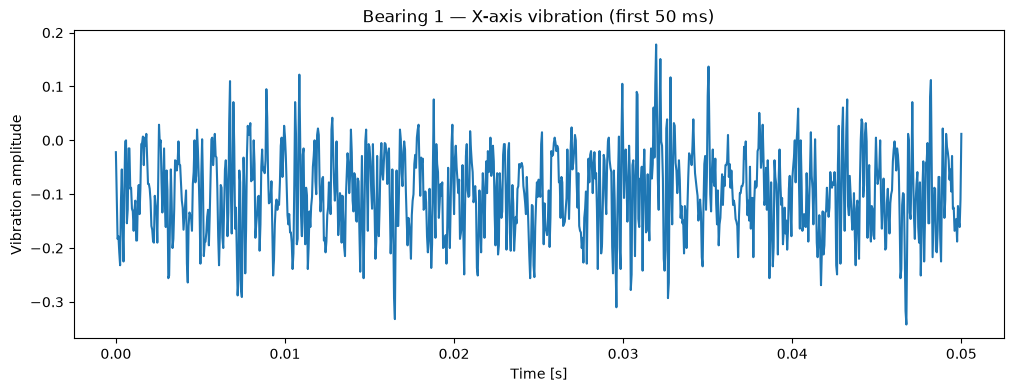

In [114]:
zoom_duration = 0.05  # seconds

mask = time <= zoom_duration

plt.figure(figsize=(12, 4))

plt.plot(time[mask], df.loc[mask, "bearing_1_x"])

plt.xlabel("Time [s]")
plt.ylabel("Vibration amplitude")
plt.title("Bearing 1 — X-axis vibration (first 50 ms)")

plt.show()

## 6. Compare vibration early and late in the experiment

The first snapshot shows the machine near the beginning of the run-to-failure experiment.

To investigate whether the vibration changes as the experiment approaches failure, we compare the same sensor channel at the beginning and at the end of Set 1.

According to the dataset documentation, Bearing 4 developed a roller-element defect by the end of the experiment.

In [115]:
late_file_path = Path("../data/raw/IMS/1st_test/2003.11.25.23.39.56")

late_file_path.exists()

True

In [116]:
df_late = pd.read_csv(
    late_file_path,
    sep="\t",
    header=None
)

In [117]:
df_late.columns = [
    "bearing_1_x",
    "bearing_1_y",
    "bearing_2_x",
    "bearing_2_y",
    "bearing_3_x",
    "bearing_3_y",
    "bearing_4_x",
    "bearing_4_y",
]

In [118]:
df["bearing_4_x"].describe()

count    20480.000000
mean        -0.090969
std          0.060086
min         -0.413000
25%         -0.129000
50%         -0.090000
75%         -0.054000
max          0.249000
Name: bearing_4_x, dtype: float64

In [119]:
df_late["bearing_4_x"].describe()

count    20480.000000
mean        -0.115535
std          0.197928
min         -1.030000
25%         -0.237000
50%         -0.115000
75%          0.007000
max          0.764000
Name: bearing_4_x, dtype: float64

### 6.1 Visual comparison of Bearing 4

We compare the same accelerometer channel from Bearing 4 at the beginning and near the end of the experiment.

Both snapshots use the same sampling rate and contain the same number of samples, allowing a direct visual comparison.

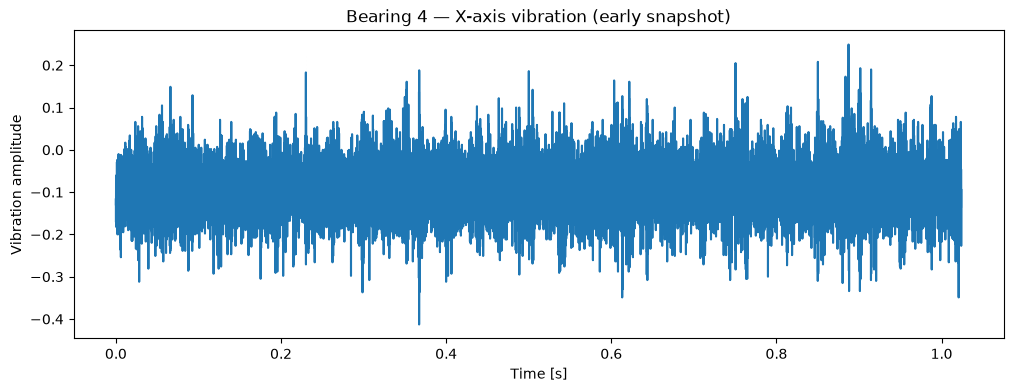

In [120]:
plt.figure(figsize=(12, 4))

plt.plot(time, df["bearing_4_x"])

plt.xlabel("Time [s]")
plt.ylabel("Vibration amplitude")
plt.title("Bearing 4 — X-axis vibration (early snapshot)")

plt.show()

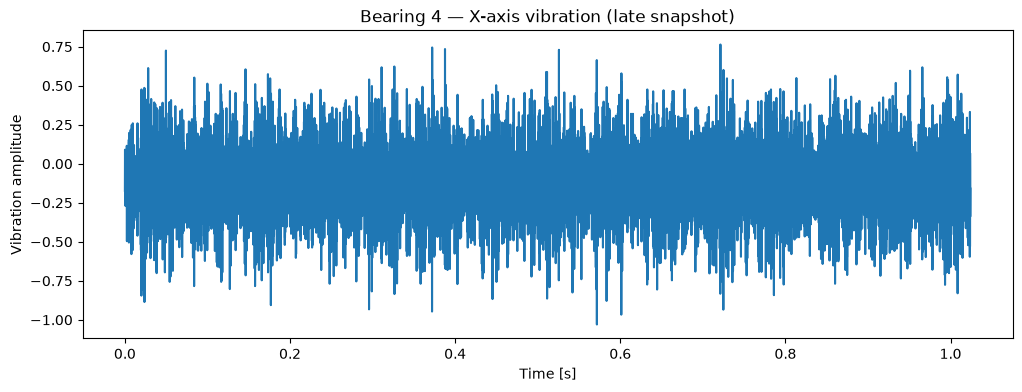

In [121]:
plt.figure(figsize=(12, 4))

plt.plot(time, df_late["bearing_4_x"])

plt.xlabel("Time [s]")
plt.ylabel("Vibration amplitude")
plt.title("Bearing 4 — X-axis vibration (late snapshot)")

plt.show()

## 7. Quantify the difference between early and late vibration

The full vibration plots are visually dense, so differences are difficult to assess reliably by eye.

We therefore compare a few basic numerical properties of the same Bearing 4 sensor at the beginning and end of the experiment.

In [122]:
early_signal = df["bearing_4_x"]
late_signal = df_late["bearing_4_x"]

print("Early snapshot")
print("Mean:", early_signal.mean())
print("Standard deviation:", early_signal.std())
print("Minimum:", early_signal.min())
print("Maximum:", early_signal.max())

print()

print("Late snapshot")
print("Mean:", late_signal.mean())
print("Standard deviation:", late_signal.std())
print("Minimum:", late_signal.min())
print("Maximum:", late_signal.max())

Early snapshot
Mean: -0.09096875
Standard deviation: 0.0600860216404936
Minimum: -0.413
Maximum: 0.249

Late snapshot
Mean: -0.11553481445312501
Standard deviation: 0.19792751228913977
Minimum: -1.03
Maximum: 0.764


## 8. Compute vibration RMS

Root Mean Square (RMS) is a common way to summarize the overall magnitude of a vibration signal.

A vibration signal contains both positive and negative values because the bearing housing moves back and forth along the sensor axis. If we calculated the ordinary mean, positive and negative values could cancel each other and make a strongly vibrating signal appear close to zero.

RMS avoids this by:

1. squaring every vibration value, so both positive and negative values become positive;
2. calculating the mean of the squared values;
3. taking the square root of that mean.

The RMS formula is:

$$
\mathrm{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N} x_i^2}
$$

where:

- $N$ is the number of samples;
- $x_i$ is the vibration value of sample $i$.

For example, consider the signal:

$$
[+0.2,\ -0.2,\ +0.2,\ -0.2]
$$

Its ordinary mean is zero because the positive and negative values cancel:

$$
\frac{0.2 - 0.2 + 0.2 - 0.2}{4} = 0
$$

However, the signal is clearly vibrating.

Using RMS:

$$
\sqrt{
\frac{
0.2^2 + (-0.2)^2 + 0.2^2 + (-0.2)^2
}{4}
}
= 0.2
$$

Therefore, RMS can be interpreted as a measure of the overall vibration magnitude, regardless of direction.

In this project, we compare the RMS of an early snapshot and a late snapshot of the same bearing to investigate whether the vibration strength increases as the bearing approaches failure.

In [123]:
early_rms = np.sqrt(np.mean(early_signal**2))
late_rms = np.sqrt(np.mean(late_signal**2))

print("Early RMS:", early_rms)
print("Late RMS:", late_rms)

Early RMS: 0.10902048975995293
Late RMS: 0.22917609084552074


### RMS interpretation

The RMS increases from approximately **0.109** in the early snapshot to **0.229** in the late snapshot.

This means that the overall vibration magnitude of Bearing 4 is substantially higher near the end of the experiment.

The late RMS is about **2.1 times** the early RMS:

$$
\frac{0.229}{0.109} \approx 2.1
$$

This single comparison suggests that the bearing vibration becomes stronger as the experiment progresses.

However, comparing only two snapshots is not sufficient to describe the full degradation process. The next step is to calculate RMS across multiple snapshots over time and observe whether a trend emerges.

## 9. Track RMS across the experiment

Comparing only the first and last snapshots gives us two isolated points.

To understand how Bearing 4 changes during the run-to-failure experiment, we now calculate RMS for several snapshots distributed across the experiment timeline.

We begin with a small sample of files before processing the entire dataset.

In [124]:
test_1_dir = Path("../data/raw/IMS/1st_test")

all_files = sorted(test_1_dir.iterdir())

len(all_files)

2156

In [125]:
indices = np.linspace(
    0,
    len(all_files) - 1,
    10,
    dtype=int
)

selected_files = [all_files[i] for i in indices]

selected_files

[PosixPath('../data/raw/IMS/1st_test/2003.10.22.12.06.24'),
 PosixPath('../data/raw/IMS/1st_test/2003.10.31.00.49.46'),
 PosixPath('../data/raw/IMS/1st_test/2003.11.01.18.21.44'),
 PosixPath('../data/raw/IMS/1st_test/2003.11.09.08.01.44'),
 PosixPath('../data/raw/IMS/1st_test/2003.11.14.22.08.46'),
 PosixPath('../data/raw/IMS/1st_test/2003.11.16.14.08.46'),
 PosixPath('../data/raw/IMS/1st_test/2003.11.19.09.12.30'),
 PosixPath('../data/raw/IMS/1st_test/2003.11.21.11.58.36'),
 PosixPath('../data/raw/IMS/1st_test/2003.11.23.08.56.56'),
 PosixPath('../data/raw/IMS/1st_test/2003.11.25.23.39.56')]

In [126]:
rms_values = []

for file in selected_files:
    snapshot = pd.read_csv(
        file,
        sep="\t",
        header=None
    )

    bearing_4_x = snapshot.iloc[:, 6]

    rms = np.sqrt(np.mean(bearing_4_x**2))

    rms_values.append(rms)

print(rms_values)

[np.float64(0.10902048975995293), np.float64(0.13736332553896982), np.float64(0.1413050946893149), np.float64(0.13622094371943141), np.float64(0.13620229651577787), np.float64(0.13403308134386543), np.float64(0.14447685868440144), np.float64(0.17369923128562992), np.float64(0.17669811564435436), np.float64(0.22917609084552074)]


### 9.1 Associate RMS values with experiment timestamps

Each RMS value corresponds to one vibration snapshot.

Since the filename contains the acquisition timestamp, we convert each selected filename into a datetime value so that RMS can be plotted against the actual experiment timeline.

In [127]:
timestamps = [
    pd.to_datetime(file.name, format="%Y.%m.%d.%H.%M.%S")
    for file in selected_files
]

timestamps

[Timestamp('2003-10-22 12:06:24'),
 Timestamp('2003-10-31 00:49:46'),
 Timestamp('2003-11-01 18:21:44'),
 Timestamp('2003-11-09 08:01:44'),
 Timestamp('2003-11-14 22:08:46'),
 Timestamp('2003-11-16 14:08:46'),
 Timestamp('2003-11-19 09:12:30'),
 Timestamp('2003-11-21 11:58:36'),
 Timestamp('2003-11-23 08:56:56'),
 Timestamp('2003-11-25 23:39:56')]

### 9.2 Visualize the RMS trend

Each point in the following plot represents one vibration snapshot from the experiment.

The x-axis shows when the snapshot was recorded, while the y-axis shows the RMS of the Bearing 4 x-axis vibration signal for that snapshot.

This allows us to observe how the overall vibration magnitude changes as the experiment progresses.

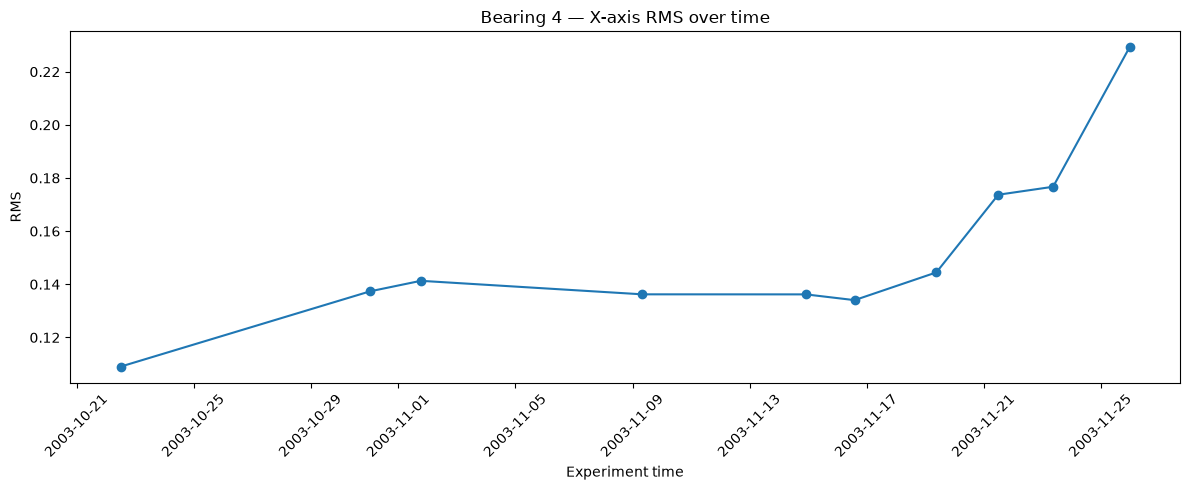

In [128]:
plt.figure(figsize=(12, 5))

plt.plot(timestamps, rms_values, marker="o")

plt.xlabel("Experiment time")
plt.ylabel("RMS")
plt.title("Bearing 4 — X-axis RMS over time")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### RMS trend interpretation

The RMS values remain relatively stable during much of the experiment, mostly around 0.13–0.14.

Toward the end of the run-to-failure experiment, the RMS begins to increase and reaches approximately 0.23 in the final selected snapshot.

This suggests that the overall vibration magnitude of Bearing 4 becomes stronger as the experiment approaches failure.

However, this plot is based on only 10 selected snapshots. To analyze the degradation pattern more reliably, the next step is to calculate RMS for all 2,156 snapshots in Set 1.

## 10. Compute RMS across the full experiment

The previous section used only 10 selected snapshots to verify the RMS calculation and visualize an approximate degradation trend.

We now apply the same calculation to all 2,156 vibration snapshots in Set 1.

For each file:

1. load the snapshot;
2. extract Bearing 4 x-axis data from the 7th column;
3. calculate one RMS value from its 20,480 samples;
4. extract the timestamp from the filename.

The result will be a time series containing one RMS value for each snapshot in the experiment.

In [129]:
full_rms_data = []

for file in all_files:
    snapshot = pd.read_csv(
        file,
        sep="\t",
        header=None
    )

    bearing_4_x = snapshot.iloc[:, 6]

    rms = np.sqrt(np.mean(bearing_4_x**2))

    timestamp = pd.to_datetime(
        file.name,
        format="%Y.%m.%d.%H.%M.%S"
    )

    full_rms_data.append({
        "timestamp": timestamp,
        "rms": rms
    })

### 10.1 Store the RMS results in a DataFrame

The loop produced one timestamp and one RMS value for each of the 2,156 snapshots.

We now convert these results into a pandas DataFrame so that the full degradation timeline can be inspected and plotted more easily.

In [132]:
rms_df = pd.DataFrame(full_rms_data)

rms_df.head()

,timestamp,rms
0,2003-10-22 12:06:24,0.109020
1,2003-10-22 12:09:13,0.108900
2,2003-10-22 12:14:13,0.110319
3,2003-10-22 12:19:13,0.111037
4,2003-10-22 12:24:13,0.110190


In [133]:
rms_df.shape

(2156, 2)

In [134]:
rms_df.tail()

,timestamp,rms
2151,2003-11-25 16:07:32,0.207455
2152,2003-11-25 23:13:21,0.222311
2153,2003-11-25 23:19:56,0.234522
2154,2003-11-25 23:29:56,0.219317
2155,2003-11-25 23:39:56,0.229176


### 10.2 Full RMS degradation trend

We now plot the RMS value of Bearing 4 x-axis for every vibration snapshot in Set 1.

Each point represents one snapshot, so the plot shows how the overall vibration magnitude evolves throughout the complete run-to-failure experiment.

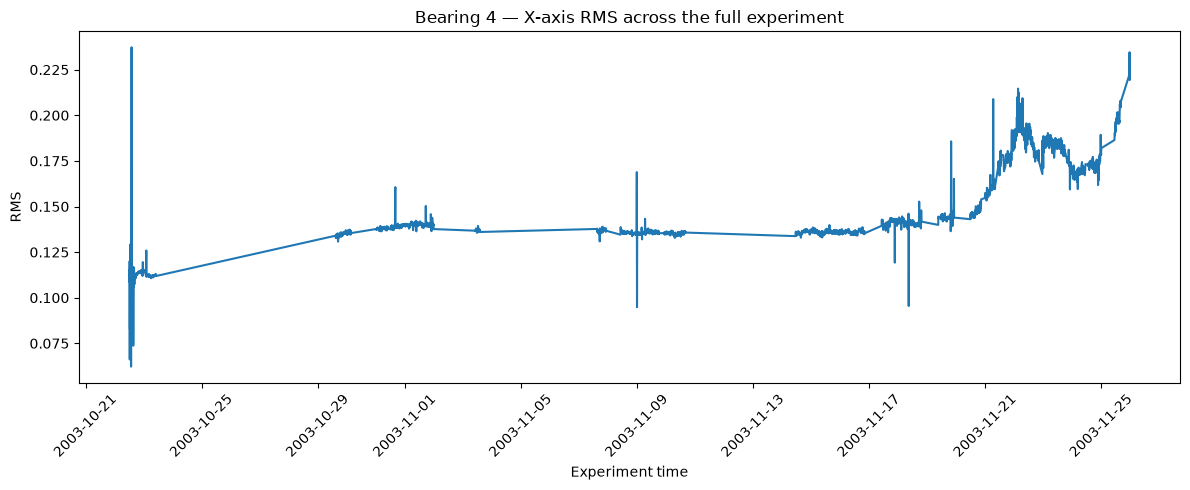

In [135]:
plt.figure(figsize=(12, 5))

plt.plot(rms_df["timestamp"], rms_df["rms"])

plt.xlabel("Experiment time")
plt.ylabel("RMS")
plt.title("Bearing 4 — X-axis RMS across the full experiment")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Full RMS trend interpretation

The RMS of Bearing 4 remains relatively stable around 0.13–0.14 during much of the experiment.

At the beginning of the experiment, there are also a few isolated high RMS values. These early peaks should not automatically be interpreted as degradation because they are not sustained across consecutive measurements.

The more distinctive behavior appears near the end of the run-to-failure experiment. From approximately November 20 onward, the RMS becomes persistently higher and reaches values above 0.20 near the final measurements.

This sustained increase suggests that the overall vibration magnitude of Bearing 4 becomes stronger as the experiment approaches failure.

The RMS trend is not perfectly monotonic: individual snapshots contain spikes and temporary decreases. Therefore, degradation should not be inferred from a single RMS measurement. A persistent change across multiple consecutive snapshots is more informative than an isolated peak.

Long straight segments in the plot correspond to gaps between measurement sessions rather than continuously recorded data.

Overall, RMS appears to be a useful condition-monitoring feature, but it should be combined with additional vibration features to describe the degradation process more reliably.